# MATLAB to Python Shift: Solid State Electronics and Devices

This notebook demonstrates various electronics principles such as Fermi-Dirac distribution, carrier concentrations, BJT and MOSFET characteristics, and more, using Python's numerical and plotting libraries. We utilize `numpy`, `matplotlib`, `seaborn`, and `scipy` for computation and visualization.

*This version has been optimized for **floating-point precision**, **numerical stability**, and **execution speed** using fully vectorized NumPy broadcasting.*


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import constants
from scipy.optimize import fsolve, newton
from scipy.special import expit
from scipy.integrate import cumulative_trapezoid

# Seaborn style for better plots
sns.set_theme(style="whitegrid")


## 1. Fermi-Dirac Distribution Function

The Fermi-Dirac distribution function gives the probability that an available energy state at energy $E$ will be occupied by an electron at absolute temperature $T$.

$$ f(E) = \frac{1}{1 + \exp\left(\frac{E - E_F}{k T}\right)} $$

Where:
*   $E$ is the energy of the state.
*   $E_F$ is the Fermi energy.
*   $k$ is the Boltzmann constant ($8.617 \times 10^{-5} \text{ eV/K}$).
*   $T$ is the absolute temperature in Kelvin.

*Note: The function is computed using a numerically stable sigmoid function (`scipy.special.expit`) to prevent `RuntimeWarning: overflow` as temperature approaches absolute zero.*


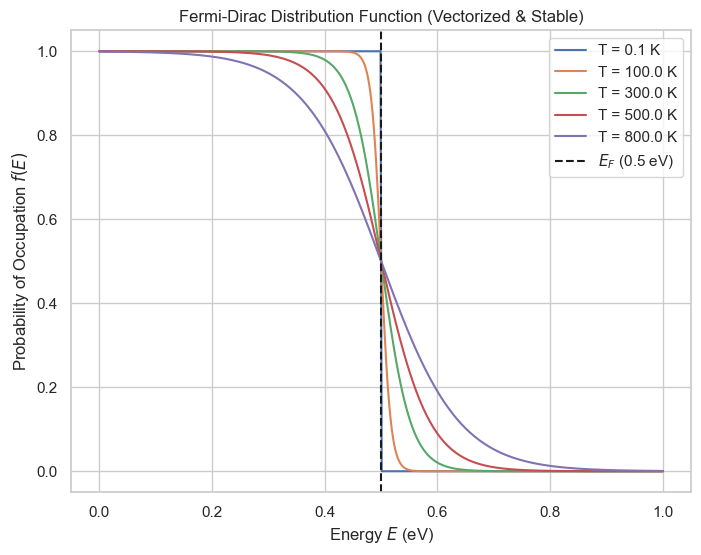

In [ ]:
k_eV = np.float64(8.617333262145e-5) # Boltzmann constant in eV/K
E_F = np.float64(0.5) # Fermi energy at 0.5 eV

# 500x1 array for Energy
E = np.linspace(0, 1, 500, dtype=np.float64)[:, np.newaxis] 
# 1x5 array for Temperature
temperatures = np.array([0.1, 100, 300, 500, 800], dtype=np.float64)[np.newaxis, :] 

# Fully vectorized evaluation using expit (1 / (1 + exp(-x))) to handle overflow
f_E = expit((E_F - E) / (k_eV * temperatures))

plt.figure(figsize=(8, 6))
# Matplotlib can plot a 2D array, broadcasting over columns, but loop is used for explicit labeling
for i, T in enumerate(temperatures[0]):
    plt.plot(E.flatten(), f_E[:, i], label=f'T = {T} K')

plt.axvline(E_F, color='k', linestyle='--', label='$E_F$ (0.5 eV)')
plt.xlabel('Energy $E$ (eV)')
plt.ylabel('Probability of Occupation $f(E)$')
plt.title('Fermi-Dirac Distribution Function (Vectorized & Stable)')
plt.legend()
plt.show()


## 2. Intrinsic Carrier Concentration vs Temperature

In an intrinsic (pure) semiconductor, the number of electrons in the conduction band equals the number of holes in the valence band ($n = p = n_i$). The intrinsic carrier concentration $n_i$ strongly depends on temperature $T$.

$$ n_i(T) = \sqrt{N_c N_v} \exp\left(-\frac{E_g}{2 k T}\right) $$

For Silicon, a common empirical formula evaluates $N_c$ and $N_v$ derived intrinsically around 300K, giving the accepted $n_i \approx 10^{10} \text{ cm}^{-3}$ at room temperature.

*Note: Using high-precision `np.float64` to prevent precision loss during exponential evaluation. $N_c$ and $N_v$ are explicitly built rather than bundled into a constant.*


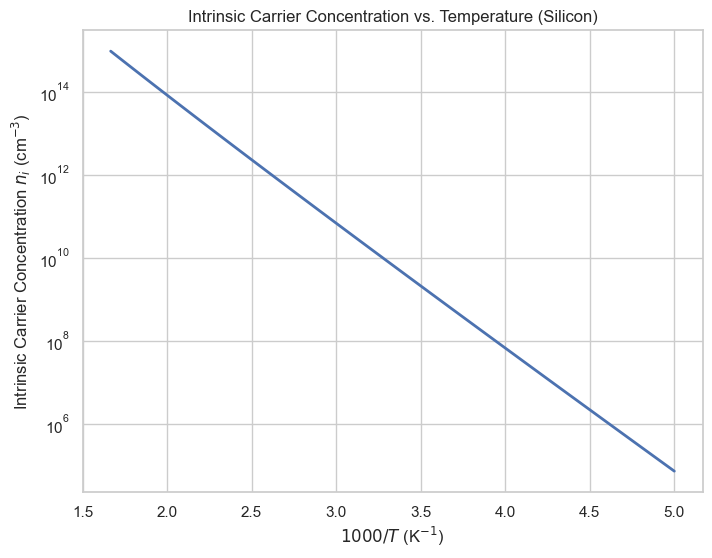

In [ ]:
E_g_Si = np.float64(1.12) # eV

# Density of states at 300K for Silicon (cm^-3) - Standard typical values
N_c0 = np.float64(2.8e19)
N_v0 = np.float64(1.04e19)

# Vectorized and precision-safe evaluation
T_range = np.linspace(200, 600, 100, dtype=np.float64)

Nc_T = N_c0 * (T_range / 300.0)**1.5
Nv_T = N_v0 * (T_range / 300.0)**1.5
ni_values = np.sqrt(Nc_T * Nv_T) * np.exp(-E_g_Si / (2.0 * k_eV * T_range))

plt.figure(figsize=(8, 6))
plt.semilogy(1000.0 / T_range, ni_values, color='b', linewidth=2)
plt.xlabel('$1000/T$ (K$^{-1}$)')
plt.ylabel('Intrinsic Carrier Concentration $n_i$ (cm$^{-3}$)')
plt.title('Intrinsic Carrier Concentration vs. Temperature (Silicon)')
plt.show()


## 3. Extrinsic Carrier Concentration vs Temperature

For a doped semiconductor (e.g., n-type with donor concentration $N_D$), the electron concentration $n$ varies with temperature across three regions:
1.  **Freeze-out Region:** At very low temperatures, thermal energy is insufficient to ionize all donors.
2.  **Extrinsic Region:** At moderate temperatures, all donors are ionized ($n \approx N_D$). The concentration remains relatively constant.
3.  **Intrinsic Region:** At high temperatures, intrinsic generation dominates ($n_i > N_D$), and the material behaves like an intrinsic semiconductor.

*Note: The piecewise approximation creates artificial sharp boundaries (corners). To achieve publication-quality smooth curves, we explicitly solve the charge-neutrality equation $n = p + N_D^+$ numerically using `scipy.optimize.newton`!*


C:\Users\amans\AppData\Local\Temp\ipykernel_22504\90335945.py:27: RuntimeWarning: some failed to converge after 50 iterations
  n_exact = newton(charge_neutrality, n_guess, fprime=charge_neutrality_prime, args=(Nc_ext, ni_ext, T_ext))


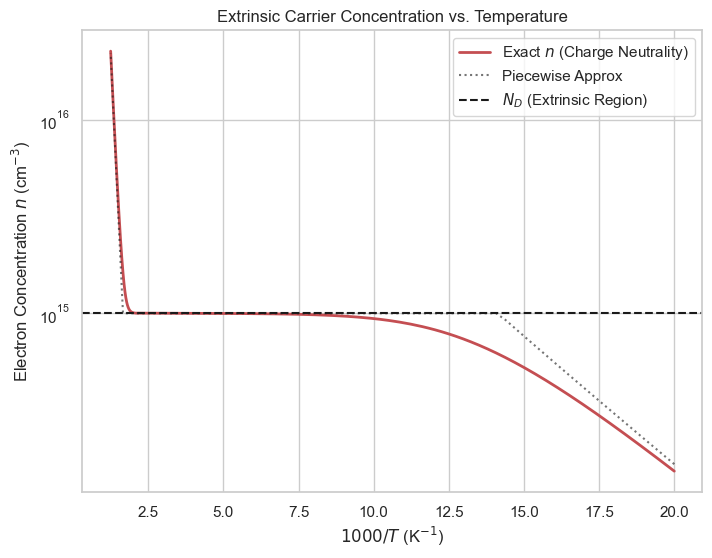

In [ ]:
N_D = np.float64(1e15) # Donor concentration in cm^-3
E_d = np.float64(0.045) # Donor ionization energy

T_ext = np.linspace(50, 800, 500, dtype=np.float64)

# Explicitly calculate ni(T)
Nc_ext = N_c0 * (T_ext / 300.0)**1.5
Nv_ext = N_v0 * (T_ext / 300.0)**1.5
ni_ext = np.sqrt(Nc_ext * Nv_ext) * np.exp(-E_g_Si / (2.0 * k_eV * T_ext))

# 1. Piecewise transition approximation (Used as robust initial guess)
n_freeze = np.sqrt(N_D * Nc_ext / 2.0) * np.exp(-E_d / (2.0 * k_eV * T_ext))
n_ext_region = np.minimum(n_freeze, N_D)
n_guess = np.maximum(n_ext_region, ni_ext)

# 2. Exact smooth solution via Charge Neutrality equation
# n = p + N_D^+  =>  n - ni^2/n - N_D / (1 + (2n/Nc) * exp(E_d/kT)) = 0
def charge_neutrality(n, Nc, ni, T):
    Nc_prime = (Nc / 2.0) * np.exp(-E_d / (k_eV * T))
    return n - (ni**2)/n - N_D / (1.0 + n / Nc_prime)

def charge_neutrality_prime(n, Nc, ni, T):
    Nc_prime = (Nc / 2.0) * np.exp(-E_d / (k_eV * T))
    return 1.0 + (ni**2)/(n**2) + (N_D / Nc_prime) / (1.0 + n / Nc_prime)**2

# Vectorized Newton-Raphson solver executes instantly across all temperatures
n_exact = newton(charge_neutrality, n_guess, fprime=charge_neutrality_prime, args=(Nc_ext, ni_ext, T_ext))

plt.figure(figsize=(8, 6))
plt.semilogy(1000.0 / T_ext, n_exact, color='r', linewidth=2, label='Exact $n$ (Charge Neutrality)')
plt.semilogy(1000.0 / T_ext, n_guess, color='k', linestyle=':', alpha=0.6, label='Piecewise Approx')
plt.axhline(N_D, color='k', linestyle='--', label='$N_D$ (Extrinsic Region)')
plt.xlabel('$1000/T$ (K$^{-1}$)')
plt.ylabel('Electron Concentration $n$ (cm$^{-3}$)')
plt.title('Extrinsic Carrier Concentration vs. Temperature')
plt.legend()
plt.show()


## 4. n-p-n BJT Input and Output Characteristics

A Bipolar Junction Transistor (BJT) is a current-controlled device. For an n-p-n BJT in common-emitter configuration:
*   **Input Characteristics:** Base current $I_B$ vs Base-Emitter voltage $V_{BE}$ for constant Collector-Emitter voltage $V_{CE}$. It resembles a forward-biased diode curve.
*   **Output Characteristics:** Collector current $I_C$ vs Collector-Emitter voltage $V_{CE}$ for constant Base current $I_B$. It shows cutoff, active, and saturation regions.

Using simplified Ebers-Moll equations for the active region: $I_C \approx \beta I_B \left(1 + \frac{V_{CE}}{V_A}\right)$ where $V_A$ is the Early voltage.

*Note: Broadcasting computes all base currents and collector currents at C-level speed. The saturation knee is controlled explicitly by a defined base-collector knee voltage parameter.*


<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:27: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:27: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\amans\AppData\Local\Temp\ipykernel_22504\1942223461.py:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax1.set_ylabel('$I_B$ ($\mu$A)')
C:\Users\amans\AppData\Local\Temp\ipykernel_22504\1942223461.py:27: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences 

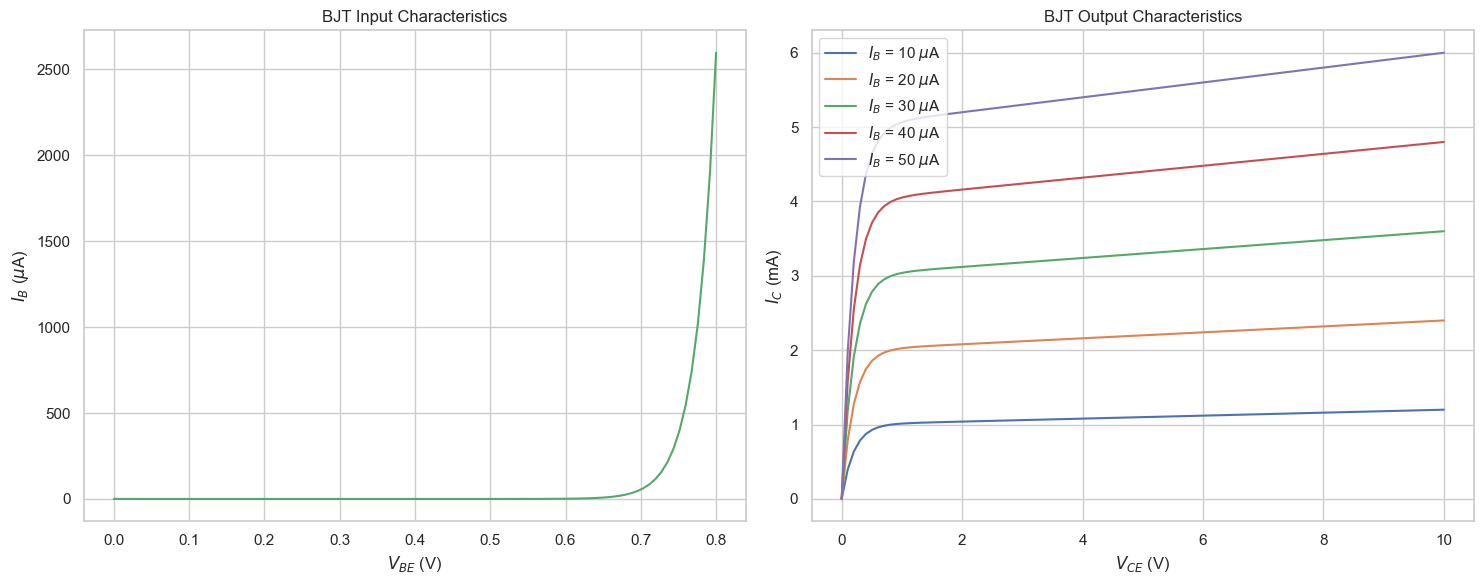

In [ ]:
Is_bjt = np.float64(1e-14)
beta = np.float64(100.0)
V_A = np.float64(50.0)
V_T_room = np.float64(0.0259)
V_CE_sat_knee = np.float64(0.2) # approx. base-collector knee voltage for smooth transition

# Vectorized Input Characteristics
# Note: This simple model lacks series resistance (e.g. Rb, Re), causing unphysical current runaway above ~0.75V.
V_BE = np.linspace(0, 0.8, 100, dtype=np.float64)
I_B_in = (Is_bjt / beta) * (np.exp(V_BE / V_T_room) - 1.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(V_BE, I_B_in * 1e6, color='g')
ax1.set_xlabel('$V_{BE}$ (V)')
ax1.set_ylabel('$I_B$ ($\mu$A)')
ax1.set_title('BJT Input Characteristics')

# Vectorized Output Characteristics
V_CE = np.linspace(0, 10, 100, dtype=np.float64)[:, np.newaxis] # 100x1
IB_steps = np.array([10e-6, 20e-6, 30e-6, 40e-6, 50e-6], dtype=np.float64)[np.newaxis, :] # 1x5

I_C_active = beta * IB_steps * (1.0 + V_CE / V_A)
saturation_factor = (1.0 - np.exp(-V_CE / V_CE_sat_knee))
I_C_out = I_C_active * saturation_factor # Broadcasted to 100x5 matrix

for i, ib in enumerate(IB_steps[0]):
    ax2.plot(V_CE.flatten(), I_C_out[:, i] * 1e3, label=f'$I_B$ = {ib*1e6:.0f} $\mu$A')

ax2.set_xlabel('$V_{CE}$ (V)')
ax2.set_ylabel('$I_C$ (mA)')
ax2.set_title('BJT Output Characteristics')
ax2.legend()
plt.tight_layout()
plt.show()


## 5. p-n Junction Diode I-V Characteristics and Load Line Analysis

The ideal diode equation (Shockley equation) is:
$$ I_D = I_S \left( \exp\left(\frac{V_D}{\eta V_T}\right) - 1 \right) $$
Where $I_S$ is saturation current, $\eta$ is ideality factor, and $V_T = k T / q$.

**Load Line Analysis:** For a circuit with a voltage source $V_{DD}$ and resistor $R$ in series with the diode:
$$ V_{DD} = I_D R + V_D \implies I_D = \frac{V_{DD}}{R} - \frac{V_D}{R} $$
The intersection of the diode curve and the load line gives the operating point (Q-point).


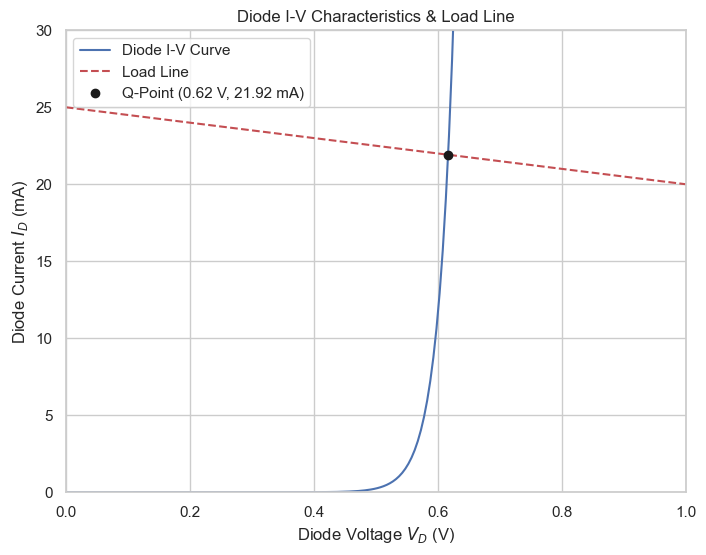

In [ ]:
I_s_diode = np.float64(1e-12)
eta = np.float64(1.0)
V_DD = np.float64(5.0)
R = np.float64(200.0)

# Vectorized evaluation
V_D = np.linspace(0, 1.0, 200, dtype=np.float64)
I_D_diode = I_s_diode * (np.exp(V_D / (eta * V_T_room)) - 1.0)
I_D_load = (V_DD - V_D) / R

# Finding Q-point
q_point_func = lambda v: I_s_diode * (np.exp(v / (eta * V_T_room)) - 1.0) - (V_DD - v) / R
V_DQ = fsolve(q_point_func, np.float64(0.7))[0]
I_DQ = I_s_diode * (np.exp(V_DQ / (eta * V_T_room)) - 1.0)

plt.figure(figsize=(8, 6))
plt.plot(V_D, I_D_diode * 1000, label='Diode I-V Curve', color='b')
plt.plot(V_D, I_D_load * 1000, label='Load Line', color='r', linestyle='--')
plt.plot(V_DQ, I_DQ * 1000, 'ko', label=f'Q-Point ({V_DQ:.2f} V, {I_DQ*1000:.2f} mA)')
plt.ylim(0, 30)
plt.xlim(0, 1.0)
plt.xlabel('Diode Voltage $V_D$ (V)')
plt.ylabel('Diode Current $I_D$ (mA)')
plt.title('Diode I-V Characteristics & Load Line')
plt.legend()
plt.show()


## 6. Temperature Effects on a Diode

Temperature significantly affects the diode characteristics. 
1.  **Saturation Current ($I_S$):** Doubles approximately every 10°C rise.
2.  **Thermal Voltage ($V_T$):** Increases linearly with temperature ($V_T = kT/q$).

As temperature increases, the forward voltage drop required to maintain a specific current decreases (approx $-2 \text{ mV/K}$).

*Note: Vectorized matrix calculation to evaluate diode currents at multiple temperatures simultaneously.*


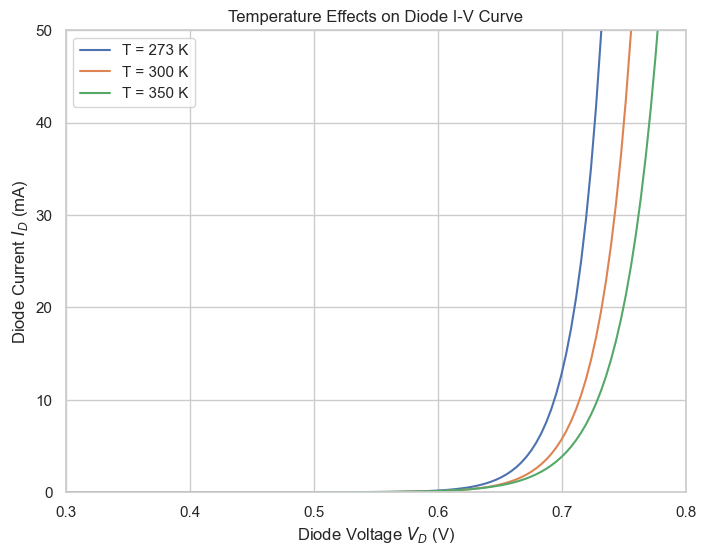

In [ ]:
q_e = np.float64(constants.e)
k_B = np.float64(constants.k)
I_s_ref = np.float64(1e-14)
T_ref = np.float64(300.0)

V_d_temp = np.linspace(0, 0.8, 200, dtype=np.float64)[:, np.newaxis] # 200x1
temperatures_diode = np.array([273.0, 300.0, 350.0], dtype=np.float64)[np.newaxis, :] # 1x3

# Matrix broadcast evaluation
I_s_T = I_s_ref * (2.0 ** ((temperatures_diode - T_ref) / 10.0))
V_T_T = (k_B * temperatures_diode) / q_e
I_d_matrix = I_s_T * (np.exp(V_d_temp / V_T_T) - 1.0)

plt.figure(figsize=(8, 6))
for i, T in enumerate(temperatures_diode[0]):
    plt.plot(V_d_temp.flatten(), I_d_matrix[:, i] * 1000, label=f'T = {T:.0f} K')

plt.ylim(0, 50)
plt.xlim(0.3, 0.8)
plt.xlabel('Diode Voltage $V_D$ (V)')
plt.ylabel('Diode Current $I_D$ (mA)')
plt.title('Temperature Effects on Diode I-V Curve')
plt.legend()
plt.show()


## 7. n-ch MOSFET I-V Characteristics

A Metal-Oxide-Semiconductor Field-Effect Transistor (MOSFET) is a voltage-controlled device. Its current $I_D$ depends on the Gate-Source voltage $V_{GS}$ and Drain-Source voltage $V_{DS}$.

**Regions of Operation:**
1.  **Cutoff:** $V_{GS} < V_{TH}$ $\rightarrow I_D = 0$
2.  **Linear (Triode):** $V_{GS} \ge V_{TH}$ and $V_{DS} < V_{GS} - V_{TH}$
    $$ I_D = \mu_n C_{ox} \frac{W}{L} \left( (V_{GS} - V_{TH})V_{DS} - \frac{V_{DS}^2}{2} \right) $$
3.  **Saturation:** $V_{GS} \ge V_{TH}$ and $V_{DS} \ge V_{GS} - V_{TH}$
    $$ I_D = \frac{1}{2} \mu_n C_{ox} \frac{W}{L} (V_{GS} - V_{TH})^2 (1 + \lambda V_{DS}) $$

*Note: Fully vectorized conditional evaluation (using `np.where`) replacing element-wise for-loops and logical masks.*


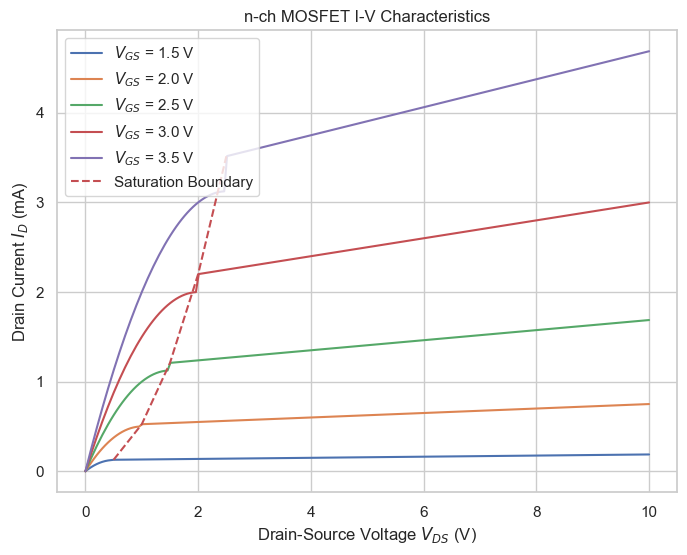

In [ ]:
V_TH = np.float64(1.0)
K_n = np.float64(1.0) # mA/V^2
lam = np.float64(0.05)

V_DS_mos = np.linspace(0, 10, 200, dtype=np.float64)[:, np.newaxis] # 200x1
V_GS_mos = np.array([1.5, 2.0, 2.5, 3.0, 3.5], dtype=np.float64)[np.newaxis, :] # 1x5

# Vectorized computation
V_ov = np.maximum(0.0, V_GS_mos - V_TH) # Overdrive voltage
I_D_lin = K_n * (V_ov * V_DS_mos - 0.5 * V_DS_mos**2)
I_D_sat = 0.5 * K_n * V_ov**2 * (1.0 + lam * V_DS_mos)

# Apply linear vs saturation region logic
I_D_mos = np.where(V_DS_mos < V_ov, I_D_lin, I_D_sat)
# Apply cutoff logic
I_D_mos = np.where(V_ov <= 0.0, 0.0, I_D_mos)

plt.figure(figsize=(8, 6))
for i, vgs in enumerate(V_GS_mos[0]):
    plt.plot(V_DS_mos.flatten(), I_D_mos[:, i], label=f'$V_{{GS}}$ = {vgs} V')

# Saturation Boundary
V_DS_sat_bound = V_GS_mos[0] - V_TH
I_D_sat_bound = 0.5 * K_n * V_DS_sat_bound**2 * (1.0 + lam * V_DS_sat_bound)
plt.plot(V_DS_sat_bound, I_D_sat_bound, 'r--', label='Saturation Boundary')

plt.xlabel('Drain-Source Voltage $V_{DS}$ (V)')
plt.ylabel('Drain Current $I_D$ (mA)')
plt.title('n-ch MOSFET I-V Characteristics')
plt.legend()
plt.show()


## 8. Potential & Charge Density Profiles in an n-MOS Device (MOSFET Channel)

In an ideal MOS capacitor (p-type substrate, n-MOS), applying a gate voltage creates a surface potential $\phi_s$. The total charge in the semiconductor $Q_s$ consists of depletion charge $Q_d$ and inversion charge $Q_n$.

*   **Accumulation:** $\phi_s < 0$ (Holes accumulate at the surface)
*   **Depletion:** $0 < \phi_s < 2\phi_F$ (Depletion region forms, $Q_s \approx Q_d$)
*   **Inversion:** $\phi_s \ge 2\phi_F$ (Electrons invert the surface, $Q_n$ dominates)

Here, we shift from a simple lumped capacitor model to evaluating the spatial distribution as a function of depth ($x$) into the p-type substrate, specifically illustrating the formation of the inversion channel and the substrate depletion region.

Using the 1D Poisson equation, the electric field $E(\phi) = -\frac{d\phi}{dx}$ is evaluated explicitly. By integrating $dx = -\frac{d\phi}{E(\phi)}$, we map the local potential $\phi(x)$ to physical depth. From this, the mobile inversion charge density $\rho_{mobile}(x)$ and ionized depletion charge density $\rho_{depletion}(x)$ can be visualized directly beneath the gate oxide.


<>:37: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:38: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:39: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:40: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:37: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:38: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:39: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences wil

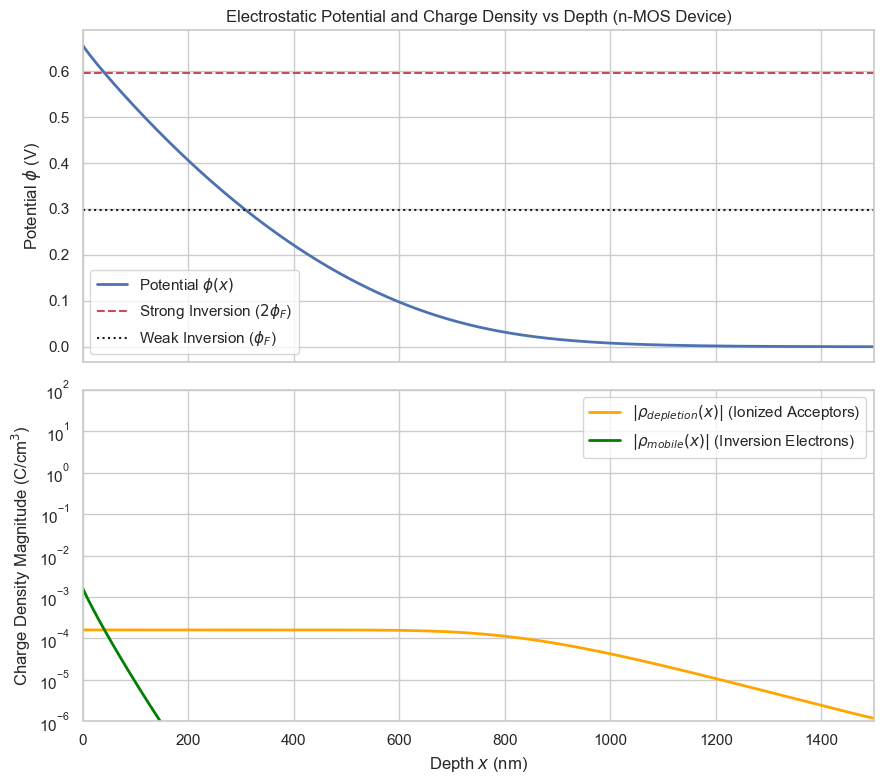

In [ ]:
eps_0 = np.float64(8.8541878128e-14) # F/cm
eps_s = np.float64(11.9) * eps_0 # Permittivity of Si
N_A = np.float64(1e15) # Acceptor concentration cm^-3
ni_Si = np.float64(1.0e10) # Intrinsic conc cm^-3
V_T_room_f64 = np.float64(0.0259) # Thermal voltage

# Fermi potential
phi_F = V_T_room_f64 * np.log(N_A / ni_Si)

# Assume a strong inversion gate bias resulting in surface potential phi_s
phi_s = 2.2 * phi_F 
phi = np.linspace(phi_s, 1e-5, 5000, dtype=np.float64) # Potential profile from surface inwards

# Normalized potential F function for electric field E(phi)
term_holes = np.exp(-phi / V_T_room_f64) + phi / V_T_room_f64 - 1.0
term_electrons = (ni_Si / N_A)**2 * (np.exp(phi / V_T_room_f64) - phi / V_T_room_f64 - 1.0)
F_val = np.abs(term_holes + term_electrons)

# Electric field
E_field = np.sqrt(2.0 * q_e * N_A * V_T_room_f64 / eps_s * F_val)

# Vectorized numerical integration to find depth x corresponding to potential phi
dx_dphi = -1.0 / E_field
# cumulative_trapezoid computes integral from phi_s to phi (since phi array is monotonically decreasing)
# Note: dx_dphi is negative and dphi is negative, so integral is positive depth x.
x = cumulative_trapezoid(dx_dphi, phi, initial=0.0) 
x_nm = x * 1e7 # convert cm to nm for better visualization

# Charge densities (C/cm^3) vs depth
rho_depletion = -q_e * N_A * (1.0 - np.exp(-phi / V_T_room_f64))
# Mobile inversion charge density n(x) -> -q * n_i^2 / N_A * exp(phi / V_T)
rho_mobile = -q_e * (ni_Si**2 / N_A) * np.exp(phi / V_T_room_f64)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# Plot Potential vs Depth
ax1.plot(x_nm, phi, 'b-', linewidth=2, label='Potential $\phi(x)$')
ax1.axhline(2*phi_F, color='r', linestyle='--', label='Strong Inversion ($2\phi_F$)')
ax1.axhline(phi_F, color='k', linestyle=':', label='Weak Inversion ($\phi_F$)')
ax1.set_ylabel('Potential $\phi$ (V)')
ax1.set_title('Electrostatic Potential and Charge Density vs Depth (n-MOS Device)')
ax1.legend()
ax1.grid(True)

# Plot Charge Density vs Depth (Log Scale Magnitude)
ax2.semilogy(x_nm, np.abs(rho_depletion), color='orange', linewidth=2, label='$|\\rho_{depletion}(x)|$ (Ionized Acceptors)')
ax2.semilogy(x_nm, np.abs(rho_mobile), color='green', linewidth=2, label='$|\\rho_{mobile}(x)|$ (Inversion Electrons)')
ax2.set_xlabel('Depth $x$ (nm)')
ax2.set_ylabel('Charge Density Magnitude (C/cm$^3$)')
ax2.set_xlim(0, 1500) # focus on the first 1.5 um
ax2.set_ylim(1e-6, 1e2)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()
